# Análisis de indicadores - gráficos de violín

In [ ]:
import pandas as pd

indicators = pd.read_excel('../tablas/registros_indicadores_completos.xlsx')
indicators

,Unnamed: 0,ID_registro,ID_indicador,ID_cooperativa,ano,mes,valor
0,0,1,Quebranto Patrimonial,CAJA COOPERATIVA CREDICOOP,2014,1,1.500449
1,1,2,Quebranto Patrimonial,CAJA COOPERATIVA PETROLERA,2014,1,1.310736
2,2,3,Quebranto Patrimonial,CASA NACIONAL DEL PROFESOR,2014,1,1.188087
3,3,4,Quebranto Patrimonial,COOPANTEX COOPERATIVA DE AHORRO Y CREDITO,2014,1,1.588034
4,4,5,Quebranto Patrimonial,COOPERATIVA AHORRO Y CREDITO GOMEZ PLATA LTDA.,2014,1,1.481415
...,...,...,...,...,...,...,...
213305,216263,37836,Relación Solvencia,COPROCENVA COOPERATIVA DE AHORRO Y CREDITO,2022,12,10.222854
213306,216264,37837,Relación Solvencia,EMPRESA COOPERATIVA DE AHORRO Y CREDITO SIGLO ...,2022,12,0.000000
213307,216265,37838,Relación Solvencia,FINANCIERA COOPERATIVA COLOMBIANA DE INGENIEROS,2022,12,16.407932
213308,216266,37839,Relación Solvencia,GRAN COOPERATIVA DE ENERGIA ELECTRICA Y RECURS...,2022,12,50.678016


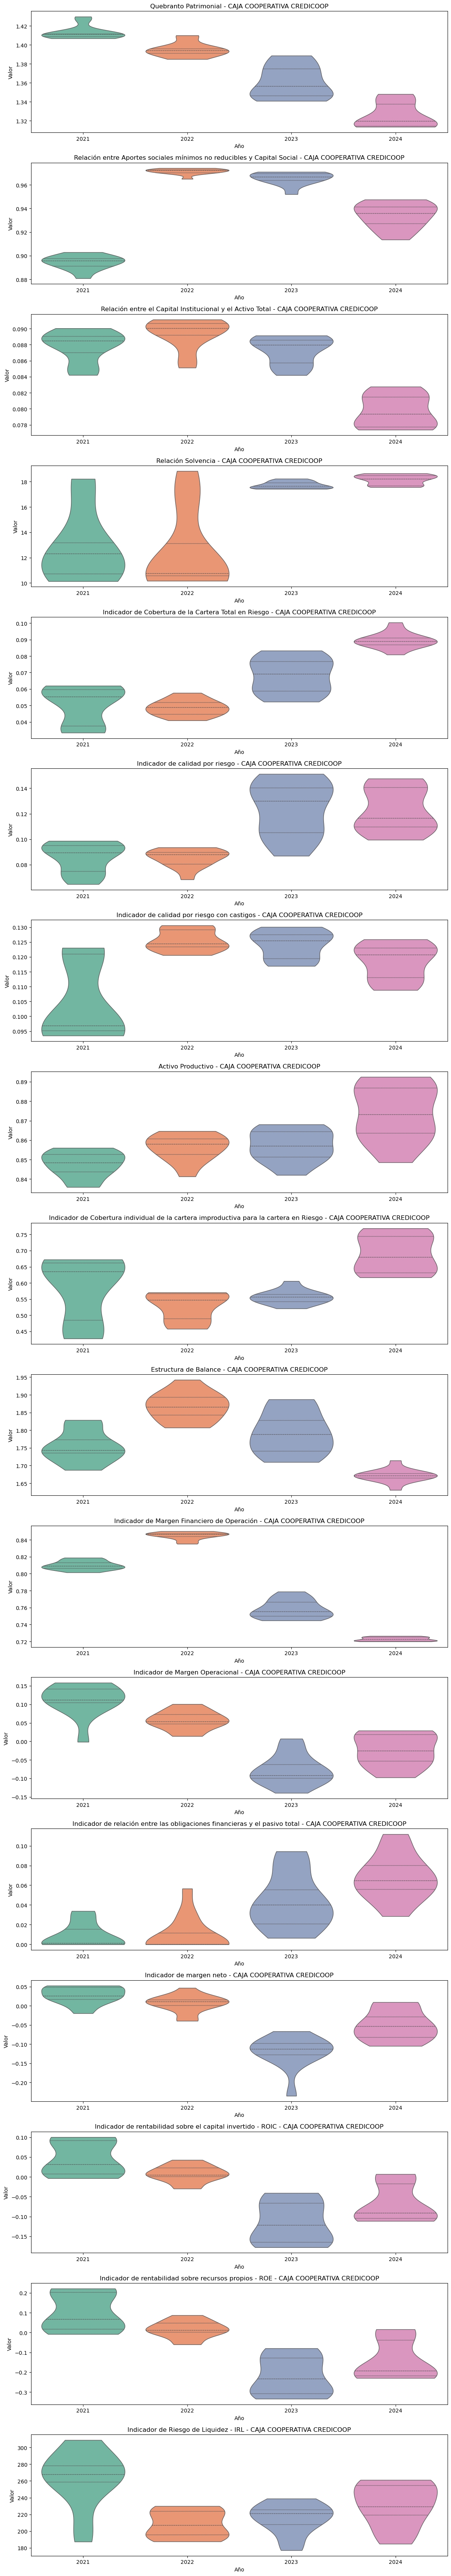

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cooperativa
cooperativa = "CAJA COOPERATIVA CREDICOOP"

# Filtrar cooperativa - años 2021 a 2024
df_coop = indicators[
    (indicators['ID_cooperativa'] == cooperativa) &
    (indicators['ano'] >= 2021) &
    (indicators['ano'] <= 2024)
]

# Indicadores únicos
indicadores_unicos = df_coop['ID_indicador'].unique()

# Configuración subplots
n_cols = 1
n_rows = len(indicadores_unicos)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

# Si solo hay un subplot
if n_rows == 1:
    axes = [axes]

for i, indicador in enumerate(indicadores_unicos):

    df_temp = df_coop[df_coop['ID_indicador'] == indicador]

    sns.violinplot(
        data=df_temp,
        x='ano',
        y='valor',
        hue='ano',
        palette='Set2',
        inner='quartile',   # muestra cuartiles
        linewidth=1,
        cut=0,              # evita colas artificiales
        density_norm='width',
        ax=axes[i]
    )

    axes[i].set_title(f"{indicador} - {cooperativa}")
    axes[i].set_xlabel("Año")
    axes[i].set_ylabel("Valor")

    # Quitar leyenda repetida
    if axes[i].get_legend():
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()